## Driver Drowsiness Detection — ResNet50V2 (Transfer Learning)
Same 6-class task as the EfficientNet-B0 notebook, but using ResNet50V2 pretrained on ImageNet.
Unlike EfficientNet, ResNet has no internal preprocessing — `preprocess_input` is applied explicitly.

In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

In [2]:
labels = os.listdir("/kaggle/input/datasets/dheerajperumandla/drowsiness-dataset/train")
print(labels)

['Closed', 'Open', 'yawn', 'no_yawn']


# IMG_SIZE = 224 for ResNet50V2

In [3]:
IMG_SIZE = 224

# for yawn and no_yawn — detect and crop face region

In [4]:
def face_for_yawn(direc="/kaggle/input/datasets/dheerajperumandla/drowsiness-dataset/train", face_cas_path="/kaggle/input/datasets/adinishad/prediction-images/haarcascade_frontalface_default.xml"):
    yaw_no = []
    categories = ["yawn", "no_yawn"]
    for category in categories:
        path_link = os.path.join(direc, category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
            face_cascade = cv2.CascadeClassifier(face_cas_path)
            faces = face_cascade.detectMultiScale(image_array, 1.3, 5)
            for (x, y, w, h) in faces:
                img = cv2.rectangle(image_array, (x, y), (x+w, y+h), (0, 255, 0), 2)
                roi_color = img[y:y+h, x:x+w]
                resized_array = cv2.resize(roi_color, (IMG_SIZE, IMG_SIZE))
                yaw_no.append([resized_array, class_num1])
    return yaw_no


yawn_no_yawn = face_for_yawn()

0
1


# for closed and open eye

In [5]:
def get_data(dir_path="/kaggle/input/datasets/dheerajperumandla/drowsiness-dataset/train", face_cas="/kaggle/input/datasets/adinishad/prediction-images/haarcascade_frontalface_default.xml", eye_cas="/kaggle/input/datasets/adinishad/prediction-images/haarcascade.xml"):
    labels = ['Closed', 'Open']
    data = []
    for label in labels:
        path = os.path.join(dir_path, label)
        class_num = labels.index(label) + 2
        print(class_num)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    return data


data_train = get_data()

2
3


# for head pose (front and down)

In [6]:
def get_head_pose_data(dir_path="/kaggle/input/datasets/antuchowdhury112/headpose/train"):
    categories = ["front", "down"]
    head_data = []
    for category in categories:
        path = os.path.join(dir_path, category)
        class_num = categories.index(category) + 4
        print(class_num)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                if img_array is None:
                    continue
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                if resized_array.shape != (IMG_SIZE, IMG_SIZE, 3):
                    continue
                head_data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    return head_data

# extend data and convert array

In [7]:
def append_data():
    yaw_no = face_for_yawn()
    data = get_data()
    head_data = get_head_pose_data()
    yaw_no.extend(data)
    yaw_no.extend(head_data)
    features = np.array([item[0] for item in yaw_no])
    labels = np.array([item[1] for item in yaw_no])
    return list(zip(features, labels))

# new variable to store

In [8]:
new_data = append_data()

0
1
2
3
4
5


# separate label and features

In [9]:
X = []
y = []
for feature, label in new_data:
    X.append(feature)
    y.append(label)

# reshape the array

In [10]:
X = np.array(X)
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

# LabelBinarizer

In [11]:
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()
y = label_bin.fit_transform(y)

# label array

In [12]:
y = np.array(y)

# train test split

In [13]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.30
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)

# length of X_test

In [14]:
len(X_test)

1847

# import dependencies

In [15]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

2026-04-26 14:58:36.265024: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777215516.459476      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777215516.514812      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777215516.967660      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777215516.967701      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777215516.967704      55 computation_placer.cc:177] computation placer alr

# Data Augmentation
ResNet50V2 has no internal normalization — `preprocess_input` scales pixels to [-1, 1].

In [16]:
train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=30
)
test_generator = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_generator.flow(np.array(X_train), y_train, batch_size=32, shuffle=False)
test_generator  = test_generator.flow(np.array(X_test),  y_test,  batch_size=32, shuffle=False)

# Model — ResNet50V2 (Transfer Learning)
## Phase 1: freeze the entire base model, train only the new head
A BatchNormalization layer is added after GAP — ResNet was designed with BN throughout.

In [17]:
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    optimizer=Adam(learning_rate=1e-3)
)

model.summary()

I0000 00:00:1777215539.480788      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15255 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,131,206 (92.05 MB)

 Trainable params: 562,310 (2.15 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

# Phase 1 Training — head only

In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    shuffle=True,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1777215551.470250     139 service.cc:152] XLA service 0x7e76ac0034f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777215551.470306     139 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777215553.399143     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/135 ━━━━━━━━━━━━━━━━━━━━ 35:25 16s/step - accuracy: 0.0312 - loss: 2.9242

I0000 00:00:1777215559.486066     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


135/135 ━━━━━━━━━━━━━━━━━━━━ 77s 456ms/step - accuracy: 0.7965 - loss: 0.5942 - val_accuracy: 0.9518 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 50s 367ms/step - accuracy: 0.9553 - loss: 0.1343 - val_accuracy: 0.9610 - val_loss: 0.1057 - learning_rate: 0.0010
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 48s 353ms/step - accuracy: 0.9647 - loss: 0.1035 - val_accuracy: 0.9675 - val_loss: 0.0894 - learning_rate: 0.0010
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 49s 361ms/step - accuracy: 0.9619 - loss: 0.1162 - val_accuracy: 0.9718 - val_loss: 0.0837 - learning_rate: 0.0010
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 47s 351ms/step - accuracy: 0.9745 - loss: 0.0721 - val_accuracy: 0.9811 - val_loss: 0.0600 - learning_rate: 0.0010
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 48s 355ms/step - accuracy: 0.9691 - loss: 0.0828 - val_accuracy: 0.9767 - val_loss: 0.0784 - learning_rate: 0.0010
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 47s 351ms/step - accuracy: 0.9764 - loss:

# Phase 2 — Fine-tuning
## Unfreeze the last 30 layers of ResNet50V2 and train with a very low learning rate

In [19]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    optimizer=Adam(learning_rate=1e-5)
)

early_stop2 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr2  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

history2 = model.fit(
    train_generator,
    epochs=40,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    shuffle=True,
    callbacks=[early_stop2, reduce_lr2]
)

Epoch 1/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 74s 422ms/step - accuracy: 0.9671 - loss: 0.1034 - val_accuracy: 0.9843 - val_loss: 0.0454 - learning_rate: 1.0000e-05
Epoch 2/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 46s 338ms/step - accuracy: 0.9814 - loss: 0.0537 - val_accuracy: 0.9854 - val_loss: 0.0418 - learning_rate: 1.0000e-05
Epoch 3/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 45s 330ms/step - accuracy: 0.9832 - loss: 0.0467 - val_accuracy: 0.9854 - val_loss: 0.0424 - learning_rate: 1.0000e-05
Epoch 4/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 46s 339ms/step - accuracy: 0.9885 - loss: 0.0315 - val_accuracy: 0.9870 - val_loss: 0.0390 - learning_rate: 1.0000e-05
Epoch 5/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 45s 334ms/step - accuracy: 0.9886 - loss: 0.0348 - val_accuracy: 0.9870 - val_loss: 0.0356 - learning_rate: 1.0000e-05
Epoch 6/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 45s 333ms/step - accuracy: 0.9923 - loss: 0.0224 - val_accuracy: 0.9854 - val_loss: 0.0407 - learning_rate: 1.0000e-05
Epoch 7/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 45s 33

# Training history — combined Phase 1 + Phase 2

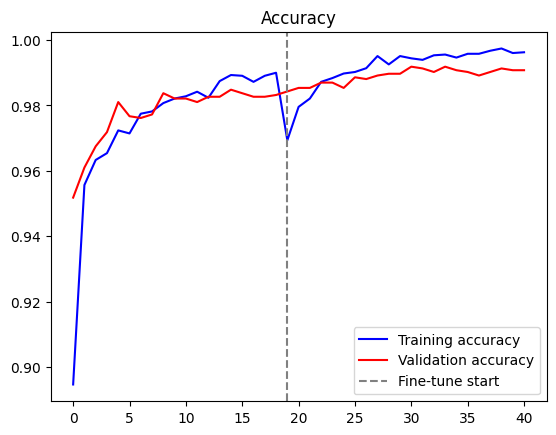

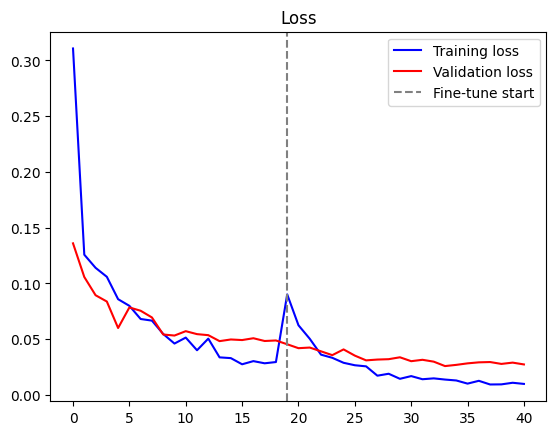

In [20]:
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
epochs   = range(len(acc))

plt.plot(epochs, acc,     'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.axvline(x=len(history1.history['accuracy']), color='gray', linestyle='--', label='Fine-tune start')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(epochs, loss,     'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.axvline(x=len(history1.history['loss']), color='gray', linestyle='--', label='Fine-tune start')
plt.legend()
plt.title('Loss')
plt.show()

# save model

In [21]:
model.save('drowsiness_resnet50v2.h5')
model.save('drowsiness_resnet50v2.keras')

# Prediction

In [22]:
# ResNet50V2 requires explicit preprocessing — no internal normalization layer
X_test_proc = preprocess_input(X_test.astype('float32'))
prediction  = np.argmax(model.predict(X_test_proc), axis=1)

58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step


# classification report

In [23]:
labels_new = ['yawn', 'no_yawn', 'Closed', 'Open', 'front', 'down']

from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis=1), prediction, target_names=labels_new))

              precision    recall  f1-score   support

        yawn       0.97      0.89      0.93        84
     no_yawn       0.90      0.97      0.94        76
      Closed       1.00      1.00      1.00       223
        Open       1.00      1.00      1.00       228
       front       1.00      0.99      1.00       594
        down       1.00      1.00      1.00       642

    accuracy                           0.99      1847
   macro avg       0.98      0.98      0.98      1847
weighted avg       0.99      0.99      0.99      1847



---
# Extended Analysis

In [24]:
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.manifold import TSNE

labels_new  = ['yawn', 'no_yawn', 'Closed', 'Open', 'front', 'down']
true_labels = np.argmax(y_test, axis=1)
# ResNet50V2 has no internal preprocessing — must apply preprocess_input before inference
X_test_proc = preprocess_input(X_test.astype('float32'))
y_prob      = model.predict(X_test_proc)
predictions = np.argmax(y_prob, axis=1)

58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


## 1. Class Distribution

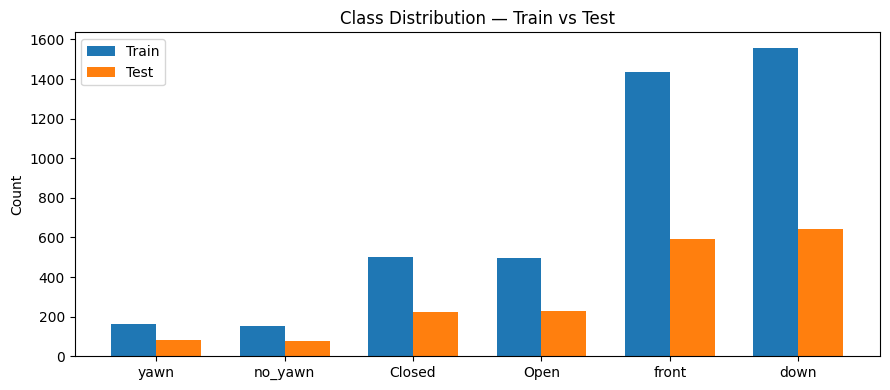

In [25]:
class_counts_train = np.bincount(np.argmax(y_train, axis=1), minlength=6)
class_counts_test  = np.bincount(true_labels, minlength=6)

x = np.arange(6)
w = 0.35
plt.figure(figsize=(9, 4))
plt.bar(x - w/2, class_counts_train, w, label='Train')
plt.bar(x + w/2, class_counts_test,  w, label='Test')
plt.xticks(x, labels_new)
plt.ylabel('Count')
plt.title('Class Distribution — Train vs Test')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Confusion Matrix

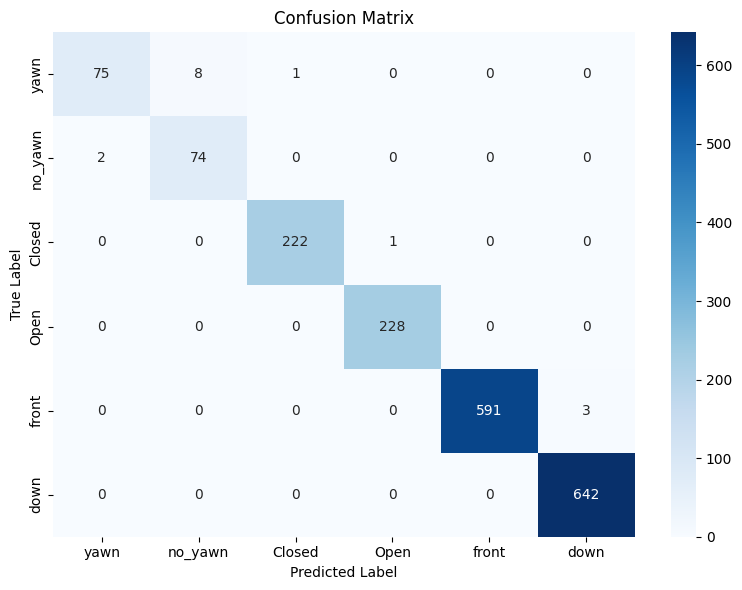

In [26]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_new, yticklabels=labels_new)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 3. Per-Class Accuracy

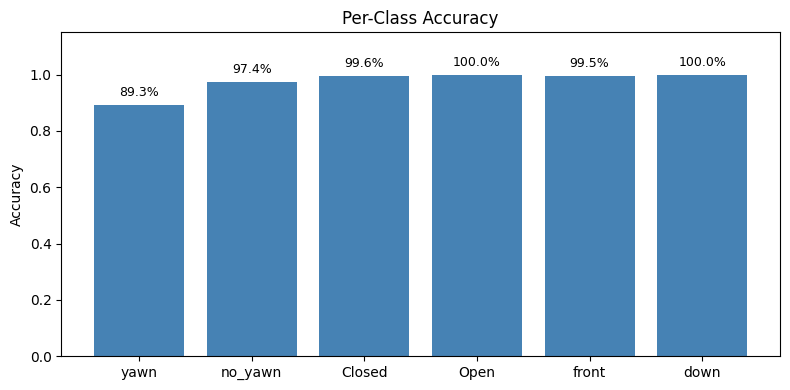

In [27]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 4))
bars = plt.bar(labels_new, per_class_acc, color='steelblue')
plt.ylim(0, 1.15)
plt.title('Per-Class Accuracy')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02,
             f'{acc:.1%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 4. ROC Curves + AUC (One-vs-Rest)

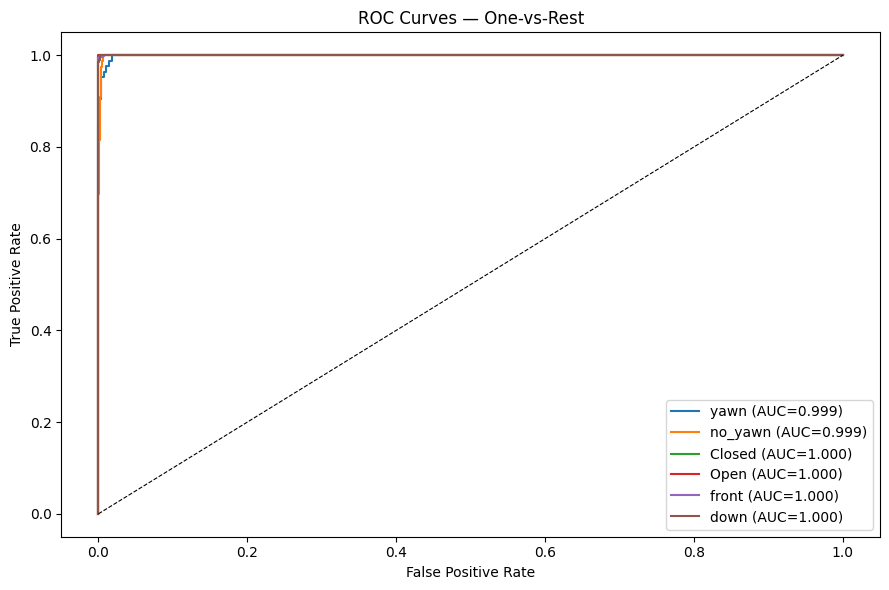

In [28]:
plt.figure(figsize=(9, 6))
for i, label in enumerate(labels_new):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — One-vs-Rest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. Precision-Recall Curves

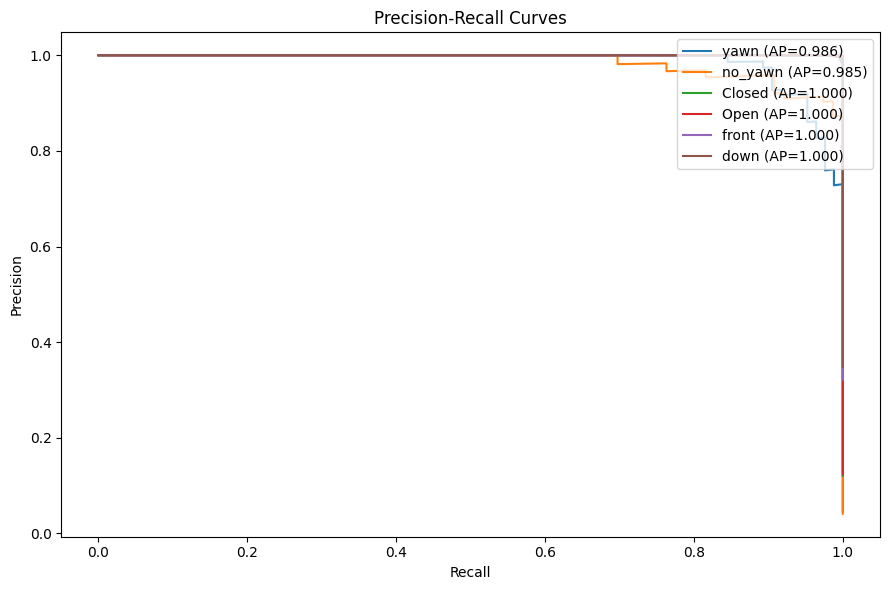

In [29]:
plt.figure(figsize=(9, 6))
for i, label in enumerate(labels_new):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_prob[:, i])
    ap = average_precision_score(y_test[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f'{label} (AP={ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Misclassification Gallery

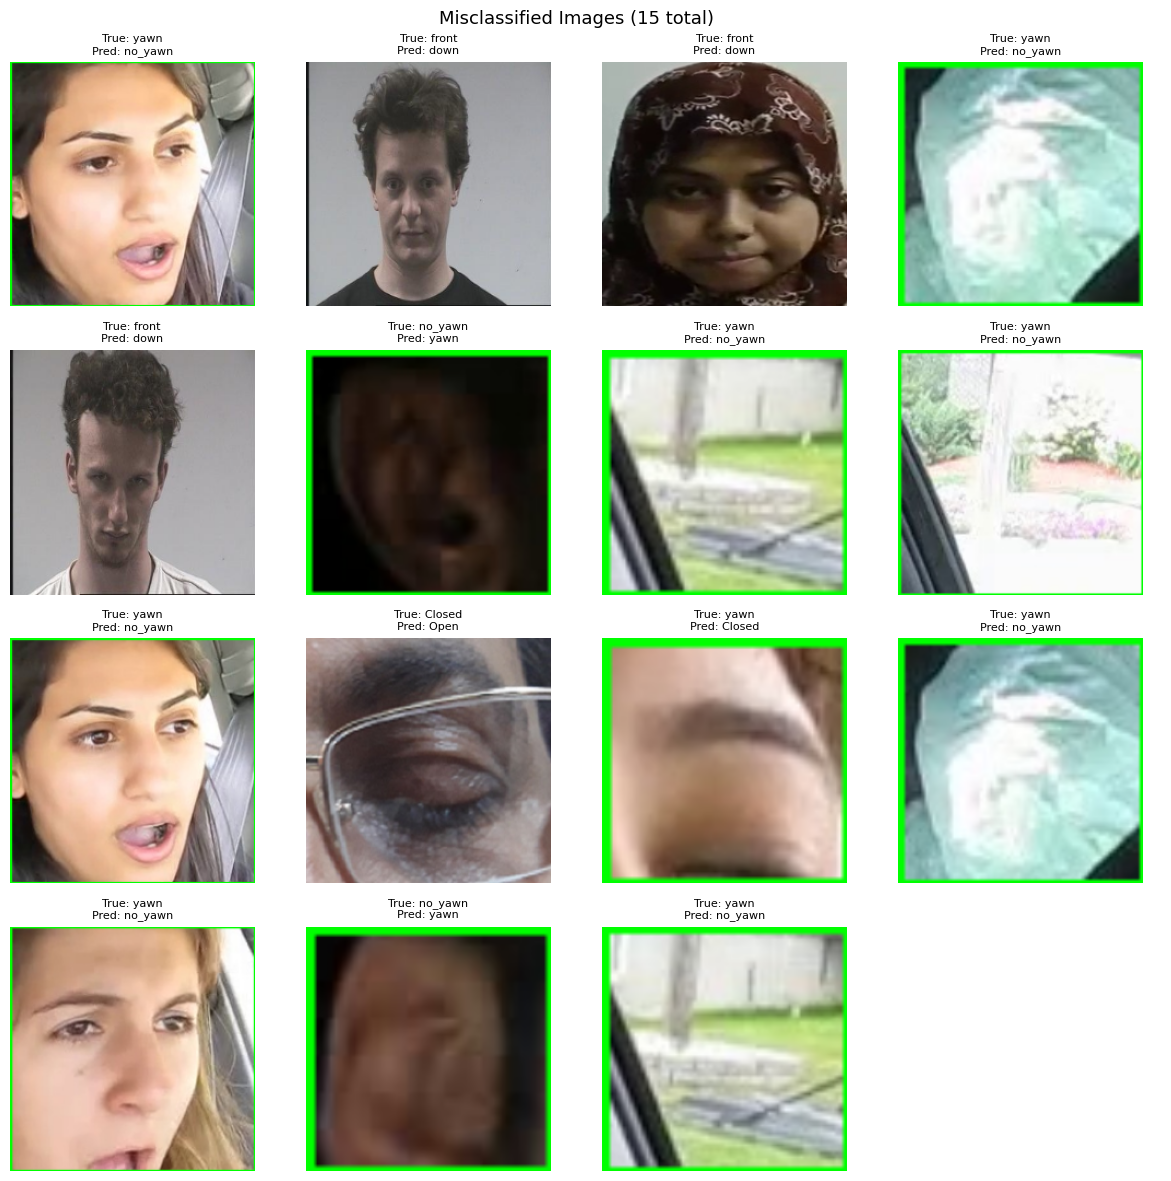

In [30]:
wrong_idx = np.where(predictions != true_labels)[0]
n_show = min(16, len(wrong_idx))

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off')
        continue
    idx = wrong_idx[i]
    img_rgb = cv2.cvtColor(X_test[idx].astype('uint8'), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(
        f'True: {labels_new[true_labels[idx]]}\nPred: {labels_new[predictions[idx]]}',
        fontsize=8
    )
    ax.axis('off')
plt.suptitle(f'Misclassified Images ({len(wrong_idx)} total)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Grad-CAM — one sample per class

Grad-CAM target layer: conv5_block3_3_conv


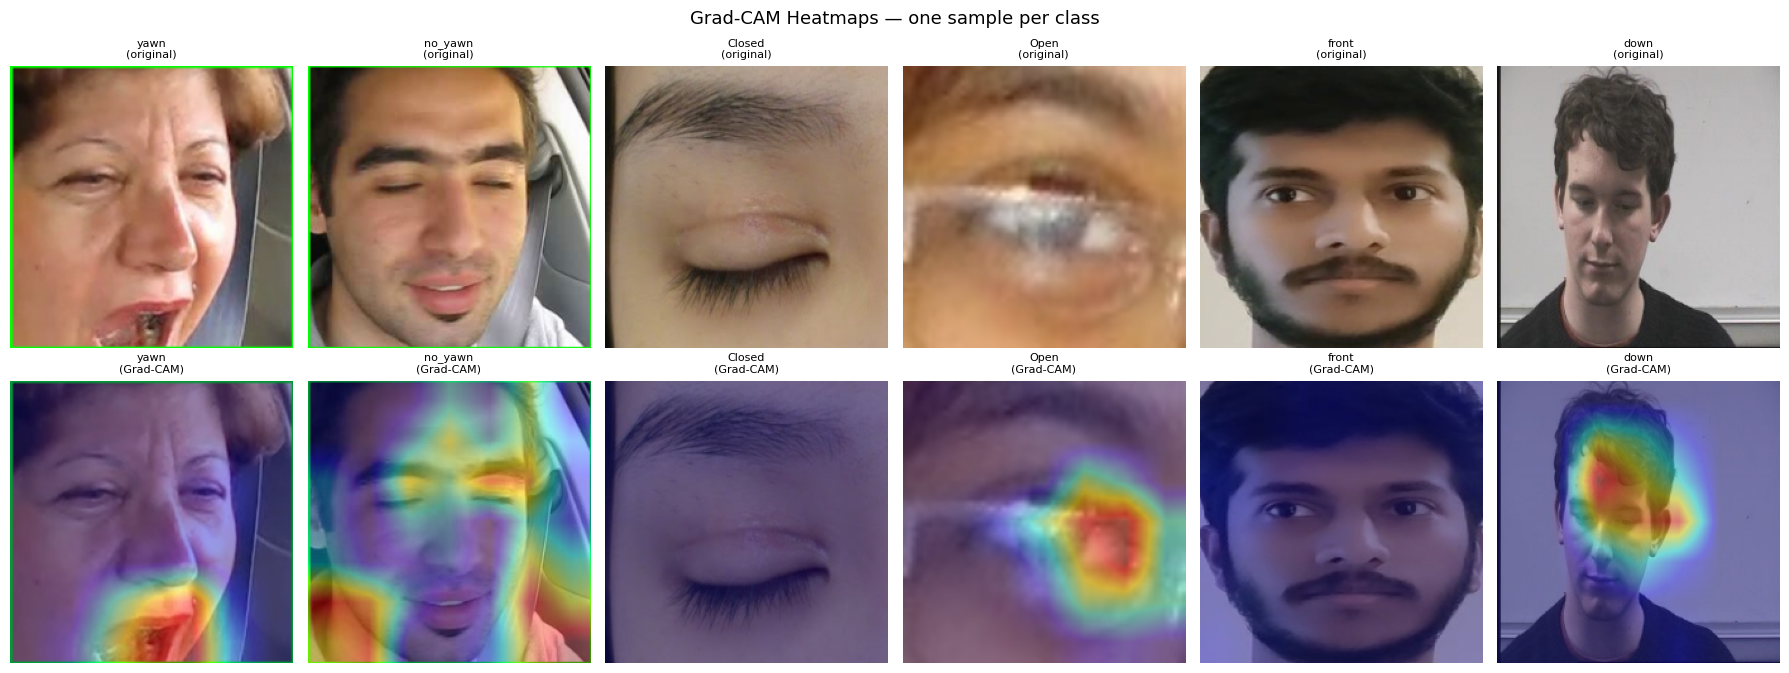

In [31]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_score = preds[:, pred_index]
    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_bgr, heatmap, alpha=0.4):
    h, w = img_bgr.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img_bgr.astype('uint8'), 1 - alpha, heatmap_colored, alpha, 0)
    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)


# dynamically find the last Conv2D layer (ResNet50V2 → last residual block conv)
last_conv_layer_name = next(
    layer.name for layer in reversed(model.layers)
    if isinstance(layer, tf.keras.layers.Conv2D)
)
print(f'Grad-CAM target layer: {last_conv_layer_name}')

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
for i, label in enumerate(labels_new):
    idxs = np.where(true_labels == i)[0]
    idx  = idxs[0]
    img_bgr   = X_test[idx].astype('uint8')
    # ResNet50V2 needs preprocess_input — apply before feeding to Grad-CAM
    img_input = preprocess_input(np.expand_dims(img_bgr.astype('float32'), axis=0))
    heatmap   = make_gradcam_heatmap(img_input, model, last_conv_layer_name)
    overlay   = overlay_gradcam(img_bgr, heatmap)

    axes[0, i].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f'{label}\n(original)', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f'{label}\n(Grad-CAM)', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Grad-CAM Heatmaps — one sample per class', fontsize=13)
plt.tight_layout()
plt.show()

## 8. t-SNE of Feature Embeddings (GAP layer)

58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


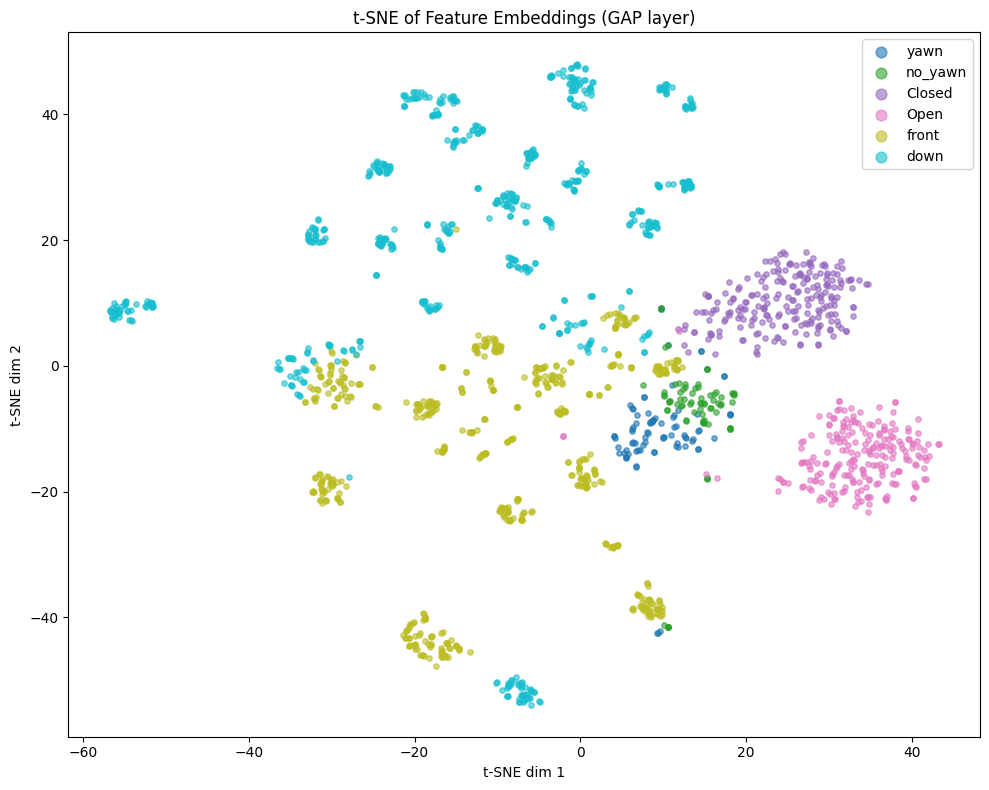

In [32]:
# build a sub-model that outputs GlobalAveragePooling2D activations
gap_layer_name = next(
    layer.name for layer in model.layers
    if isinstance(layer, tf.keras.layers.GlobalAveragePooling2D)
)
feature_extractor = tf.keras.models.Model(
    inputs=model.input,
    outputs=model.get_layer(gap_layer_name).output
)

n_tsne     = min(2000, len(X_test))
idx_subset = np.random.choice(len(X_test), n_tsne, replace=False)
# ResNet50V2: apply preprocess_input before extracting features
embeddings = feature_extractor.predict(
    preprocess_input(X_test[idx_subset].astype('float32'))
)

tsne   = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=1000)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 6))
for i, label in enumerate(labels_new):
    mask = true_labels[idx_subset] == i
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                c=[colors[i]], label=label, alpha=0.6, s=15)
plt.legend(markerscale=2)
plt.title('t-SNE of Feature Embeddings (GAP layer)')
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

# predicting function

In [33]:
labels_new = ['yawn', 'no_yawn', 'Closed', 'Open', 'front', 'down']

def prepare(filepath):
    img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
    resized   = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE)).astype('float32')
    # ResNet50V2 requires explicit preprocessing
    resized   = preprocess_input(resized)
    return resized.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

model = tf.keras.models.load_model('drowsiness_resnet50v2.h5')

# Prediction
## 0-yawn, 1-no_yawn, 2-Closed, 3-Open, 4-front, 5-down

In [34]:
prediction = model.predict([prepare('/kaggle/input/datasets/dheerajperumandla/drowsiness-dataset/train/no_yawn/1028.jpg')])
np.argmax(prediction)

[ WARN:0@2223.102] global loadsave.cpp:278 findDecoder imread_('../input/drowsiness-dataset/train/no_yawn/1067.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [ ]:
prediction = model.predict([prepare('/kaggle/input/datasets/dheerajperumandla/drowsiness-dataset/train/Closed/_108.jpg')])
np.argmax(prediction)

In [ ]:
prediction = model.predict([prepare('/kaggle/input/datasets/dheerajperumandla/drowsiness-dataset/train/Open/_111.jpg')])
np.argmax(prediction)

In [ ]:
prediction = model.predict([prepare('/kaggle/input/datasets/dheerajperumandla/drowsiness-dataset/train/yawn/109.jpg')])
np.argmax(prediction)